In [1]:
import rebound
import reboundx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
pd.set_option('display.precision', 20)

# Collisions with new mass less than min_frag_mass and collisions with the sun

## randseed = 1

In [2]:
def get_abs(a, b, c):
    return (a**2 + b**2 + c**2)**0.5

In [3]:
famtree_bigstep_1 = pd.read_csv(
    "famtree_bigstep_1",
    header=None, 
    names=[
        "t", "type", "new_id", "parent1_id", "parent2_id",
        "new_mass", "parent1_mass", "parent2_mass", "new_radius",
        "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
    ]
)

In [4]:
heartbeat_column_names = [
    "t", "walltime", "N", "total_mass", 
    "ang_mom_x", "ang_mom_y", "ang_mom_z", "energy", 
    "p3_m", "p3_r", "p3_x", "p3_y", "p3_z", "p3_vx", "p3_vy", "p3_vz",
    "p0_m", "p0_r", "p0_x", "p0_y", "p0_z", "p0_vx", "p0_vy", "p0_vz"
]

# Read the files
heartbeat_bigstep_1 = pd.read_csv(
    "heartbeat_bigstep_1", 
    names=heartbeat_column_names, 
    header=None
)

In [5]:
# 1. Get initial values (from the first row)
initial_mass = heartbeat_bigstep_1["total_mass"].iloc[0]
initial_energy = heartbeat_bigstep_1["energy"].iloc[0]

L_x0 = heartbeat_bigstep_1["ang_mom_x"].iloc[0]
L_y0 = heartbeat_bigstep_1["ang_mom_y"].iloc[0]
L_z0 = heartbeat_bigstep_1["ang_mom_z"].iloc[0]
initial_L_mag = np.sqrt(L_x0**2 + L_y0**2 + L_z0**2)

# 2. Calculate current angular momentum magnitude for all rows
current_L_mag = np.sqrt(
    heartbeat_bigstep_1["ang_mom_x"]**2 + 
    heartbeat_bigstep_1["ang_mom_y"]**2 + 
    heartbeat_bigstep_1["ang_mom_z"]**2
)

# 3. Add the relative error columns
heartbeat_bigstep_1["mass_error"] = abs((heartbeat_bigstep_1["total_mass"] - initial_mass) / initial_mass)
heartbeat_bigstep_1["energy_error"] = abs((heartbeat_bigstep_1["energy"] - initial_energy) / initial_energy)
heartbeat_bigstep_1["angular_momentum_error"] = abs((current_L_mag - initial_L_mag) / initial_L_mag)

In [6]:
famtree_less_than_min_mass = famtree_bigstep_1[famtree_bigstep_1['new_mass'] < 1.4e-8]
famtree_less_than_min_mass

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
44,24278.95000000000072759576,8,90,65,66,0.0000000002880145,0.00000004552382,0.00000003389238,0.000002387874,0.000012910790,0.000011701480,9.77533999999999991815,0.79900309999999996613
50,24284.31999999999970896170,8,97,95,94,0.0000000016207710,0.00000001584543,0.00000001579184,0.000004247309,0.000009081857,0.000009071608,2.13449199999999983390,0.71076700000000003765


In [7]:
coll_newid_90 = famtree_less_than_min_mass[famtree_less_than_min_mass['new_id'] == 90]
coll_newid_90

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
44,24278.95000000000072759576,8,90,65,66,0.0000000002880145,0.00000004552382,0.00000003389238,0.000002387874,0.00001291079,0.00001170148,9.77533999999999991815,0.79900309999999996613


In [18]:
famtree_with_sun = famtree_bigstep_1[(np.isclose(famtree_bigstep_1['parent1_mass'], 1)) | (np.isclose(famtree_bigstep_1['parent2_mass'], 1))]
famtree_with_sun

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
43,24276.65000000000145519152,3,88,0,85,1.0,1.0,0.0000000421381,0.00464999999999999962,0.00464999999999999962,0.00001258244,132.45990000000000463842,0.10535780000000000145


In [20]:
coll_newid_88 = famtree_with_sun[famtree_with_sun['new_id'] == 88]
coll_newid_88

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
43,24276.65000000000145519152,3,88,0,85,1.0,1.0,0.0000000421381,0.00464999999999999962,0.00464999999999999962,0.00001258244,132.45990000000000463842,0.10535780000000000145


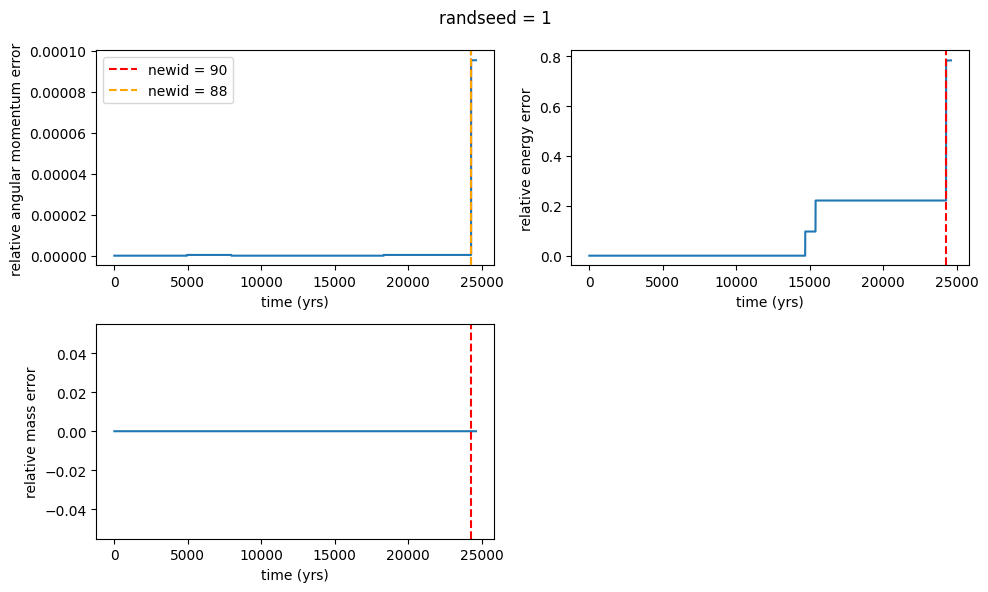

: 

In [ ]:
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.plot(heartbeat_bigstep_1['t'], heartbeat_bigstep_1['angular_momentum_error'])
plt.axvline(coll_newid_90['t'].iloc[0], color = 'red', linestyle = '--', label = 'newid = 90')
plt.axvline(coll_newid_88['t'].iloc[0], color = 'orange', linestyle = '--', label = 'newid = 88')
plt.legend()
plt.xlabel("time (yrs)")
plt.ylabel("relative angular momentum error")

plt.subplot(2,2,2)
plt.plot(heartbeat_bigstep_1['t'], heartbeat_bigstep_1['energy_error'])
plt.axvline(heartbeat_newid_90['t'].iloc[0], color = 'red', linestyle = '--')
plt.xlabel("time (yrs)")
plt.ylabel("relative energy error")

plt.subplot(2,2,3)
plt.plot(heartbeat_bigstep_1['t'], heartbeat_bigstep_1['mass_error'])
plt.axvline(heartbeat_newid_90['t'].iloc[0], color = 'red', linestyle = '--')
plt.xlabel("time (yrs)")
plt.ylabel("relative mass error")

plt.suptitle("randseed = 1")
plt.tight_layout()